# Alzheimer's Disease Brain MRI Segmentation
## FCN (Fully Convolutional Network) | OASIS disc1 + disc2
Full pipeline: data loading → preprocessing → model training → metrics → visualizations

**Note:** EarlyStopping disabled — model trains for the full configured epochs as instructed.

**Architecture note:** FCN (Long et al., 2015) was the original architecture that proved fully-convolutional networks could do end-to-end pixel-wise segmentation. It is the simplest of all 6 models in this benchmark — a VGG16 encoder followed by a small number of **coarse upsampling (transposed conv) steps**, with **at most one skip-connection-style fusion** (FCN-8s fuses 3 pooling stages). No dense decoder, no nested skips, no unpooling indices — just upsample-and-add. This makes it a useful lower-bound baseline against UNet, UNet++, and SegNet.

## 1. Import Libraries

In [1]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, BatchNormalization, Dropout, Activation, Add, Cropping2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

2026-06-20 13:28:16.976536: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781962097.148718      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781962097.197427      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781962097.577676      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781962097.577718      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781962097.577721      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [2]:
# ─── Paths ────────────────────────────────────────────────────────────────────
ROOTS = [
    '/kaggle/input/datasets/maheswarimudadla/oasis-disc1/disc1',
    '/kaggle/input/datasets/maheswarimudadla/disc2-oasis11/disc2',
]

PROCESSED_DIR   = 'oasis_processed'
IMAGE_FOLDER    = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER     = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR   = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR  = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR    = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR   = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.15

print('Config set ✓')

Config set ✓


## 3. Load & Preprocess OASIS Data (disc1 + disc2)
OASIS stores brain volumes as Analyze `.img/.hdr` pairs. We slice along the coronal axis and save each 2-D slice as a PNG.

In [3]:
def make_dir(path):
    os.makedirs(path, exist_ok=True)

for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    make_dir(d)

print('Directories ready ✓')

Directories ready ✓


In [4]:
def normalize_slice(arr):
    """Min-max normalise a 2-D array to [0, 255] uint8."""
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def extract_slices(subject_dir, img_out, mask_out, step=2):
    """
    For one OASIS subject directory, find the T88 masked brain volume
    and the FSL_SEG tissue mask, then save every `step`-th coronal slice.
    Returns number of slices saved.
    """
    subject_name = os.path.basename(subject_dir)
    t88_dir = os.path.join(subject_dir, 'PROCESSED', 'MPRAGE', 'T88_111')
    fsl_dir = os.path.join(subject_dir, 'FSL_SEG')

    if not os.path.isdir(t88_dir) or not os.path.isdir(fsl_dir):
        return 0

    brain_img_path = None
    for f in os.listdir(t88_dir):
        if f.endswith('masked_gfc.img'):
            brain_img_path = os.path.join(t88_dir, f)
            break

    seg_img_path = None
    for f in os.listdir(fsl_dir):
        if f.endswith('fseg.img'):
            seg_img_path = os.path.join(fsl_dir, f)
            break

    if brain_img_path is None or seg_img_path is None:
        return 0

    brain_vol = np.squeeze(nib.load(brain_img_path).get_fdata())
    seg_vol   = np.squeeze(nib.load(seg_img_path).get_fdata())

    saved = 0
    for i in range(0, brain_vol.shape[1], step):
        b_sl   = brain_vol[:, i, :]
        seg_sl = seg_vol[:, i, :]

        if b_sl.max() == 0:
            continue

        img_arr  = normalize_slice(b_sl)
        mask_arr = (seg_sl > 0).astype(np.uint8) * 255

        fname = f"{subject_name}_sl{i:03d}.png"
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1

    return saved


# ─── Clear old slices (fresh run) ──────────────────────────────────────────────
for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# ─── Gather subjects from both discs ───────────────────────────────────────────
subject_dirs = []
for root in ROOTS:
    if os.path.exists(root):
        dirs = [
            os.path.join(root, d)
            for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d)) and d.startswith('OAS')
        ]
        subject_dirs += dirs
        print(f'{root} → {len(dirs)} subjects')

print(f'\nTotal subjects: {len(subject_dirs)}')

# ─── Extract ────────────────────────────────────────────────────────────────────
total_slices = 0
for subj in tqdm(subject_dirs, desc='Extracting slices'):
    total_slices += extract_slices(subj, IMAGE_FOLDER, MASK_FOLDER)

print(f'\nTotal slices extracted : {total_slices}')
print(f'Images saved           : {len(os.listdir(IMAGE_FOLDER))}')
print(f'Masks  saved           : {len(os.listdir(MASK_FOLDER))}')

/kaggle/input/datasets/maheswarimudadla/oasis-disc1/disc1 → 39 subjects
/kaggle/input/datasets/maheswarimudadla/disc2-oasis11/disc2 → 38 subjects

Total subjects: 77


Extracting slices:   0%|          | 0/77 [00:00<?, ?it/s]


Total slices extracted : 6622
Images saved           : 6622
Masks  saved           : 6622


## 4. Data Visualisation

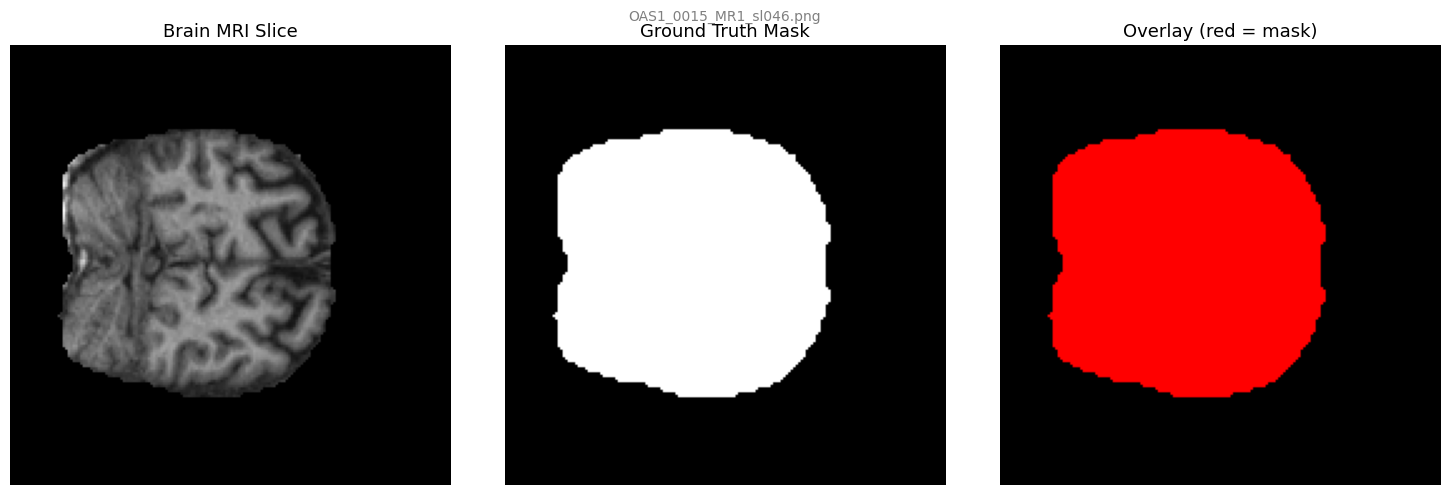

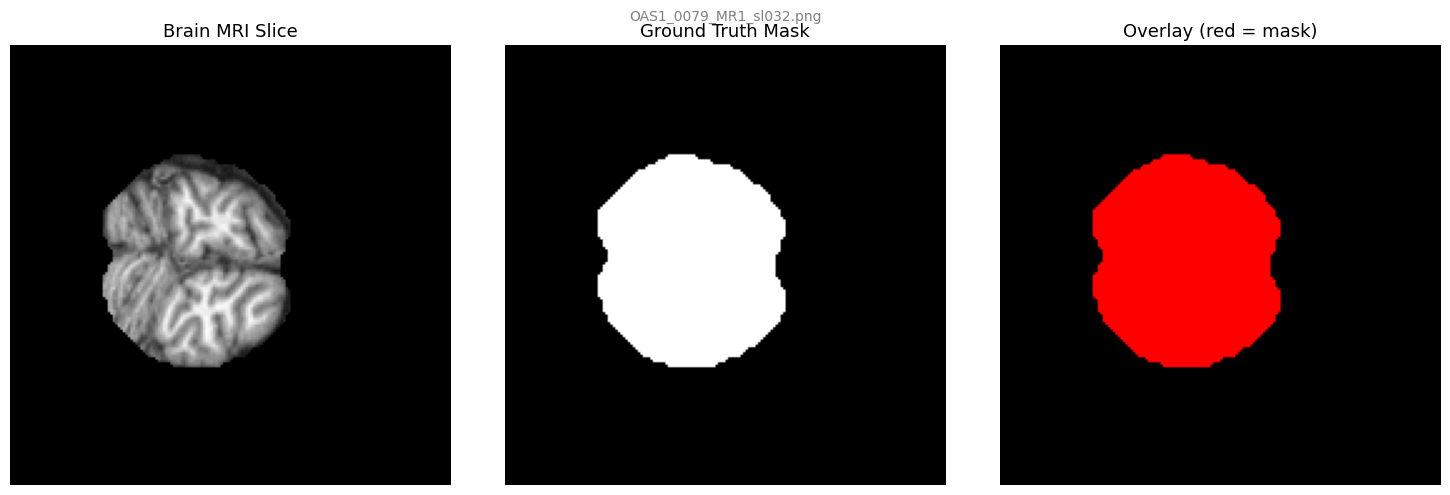

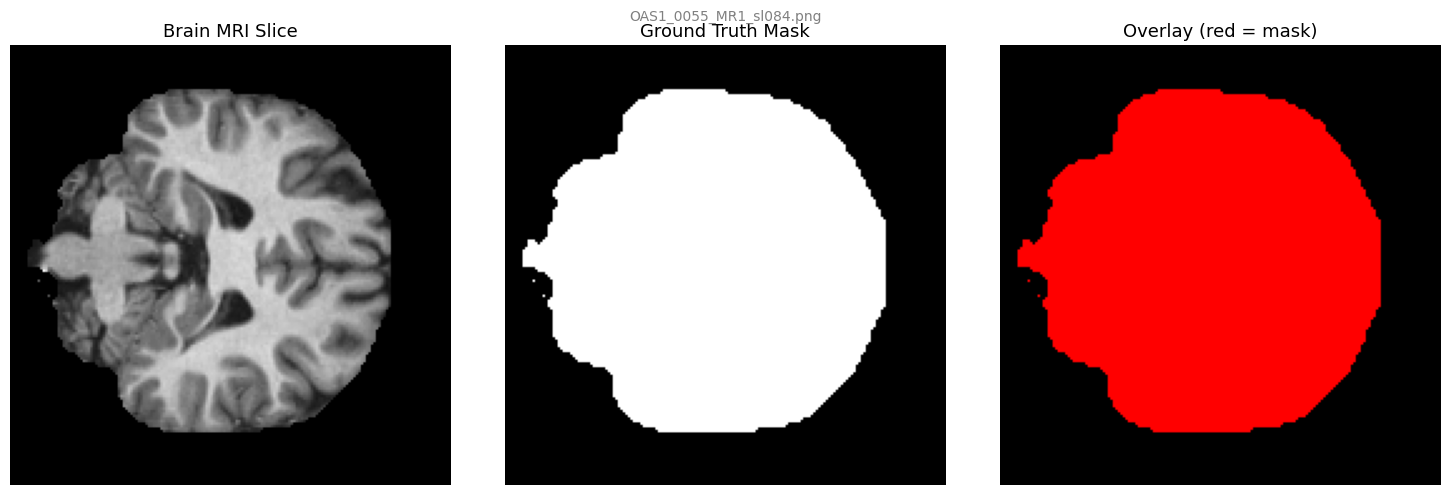

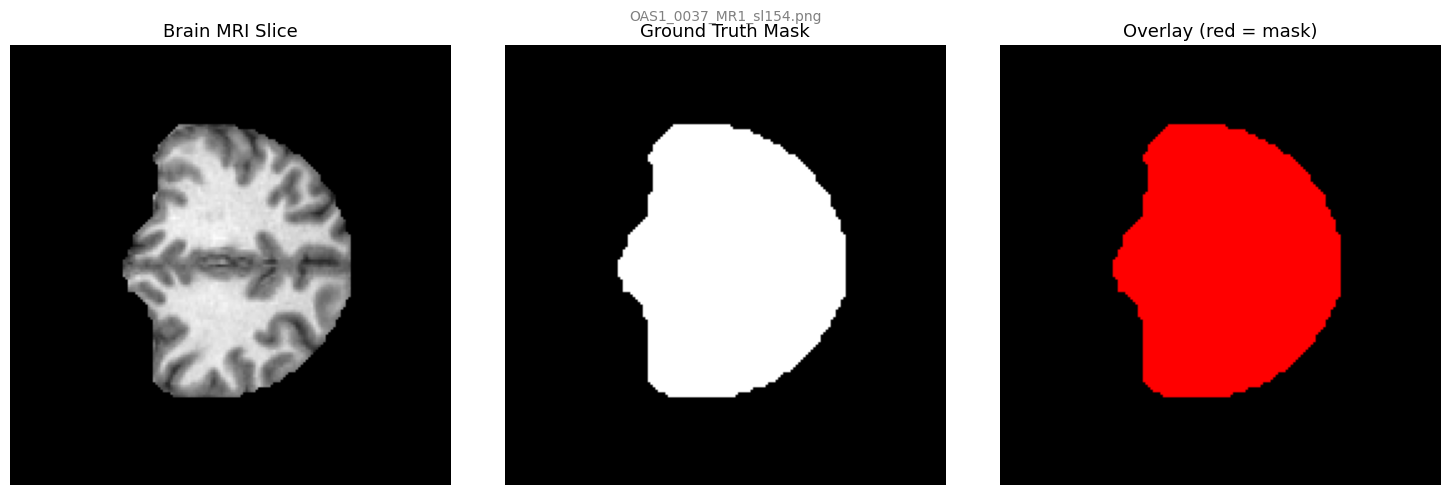

In [5]:
def visualize_sample(image_name, img_dir=IMAGE_FOLDER, mask_dir=MASK_FOLDER):
    img  = cv2.imread(os.path.join(img_dir,  image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(mask_dir, image_name), cv2.IMREAD_GRAYSCALE)

    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay[mask > 127, 0] = 255
    overlay[mask > 127, 1] = 0
    overlay[mask > 127, 2] = 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img,     cmap='gray');  axes[0].set_title('Brain MRI Slice',      fontsize=13)
    axes[1].imshow(mask,    cmap='gray');  axes[1].set_title('Ground Truth Mask',    fontsize=13)
    axes[2].imshow(overlay);               axes[2].set_title('Overlay (red = mask)', fontsize=13)
    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [6]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch! Check filenames.'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 5628  |  Test: 994


  0%|          | 0/5628 [00:00<?, ?it/s]

  0%|          | 0/994 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline

In [7]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])

    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes →  images:', imgs.shape, ' masks:', masks.shape)

I0000 00:00:1781962138.339403      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready ✓
Batch shapes →  images: (16, 224, 224, 3)  masks: (16, 224, 224, 1)


## 7. Model — FCN-8s (VGG16 backbone + skip-fused transposed-conv upsampling)
**How FCN differs from the other 5 models in this benchmark:**
- **No dense decoder.** UNet/UNet++ rebuild a full mirror-image decoder with conv blocks at every resolution. FCN instead takes 3 coarse prediction maps (from pool3, pool4, and the final bottleneck) and **fuses them by upsampling + addition** — far fewer decoder parameters.
- **Coarsest of the segmentation outputs before refinement** — the original FCN-32s variant (bottleneck only, no fusion) is known to produce blocky, low-detail masks. FCN-8s (used here) fixes this by fusing 3 stages, which is the standard configuration from the original paper.
- **Transposed convolutions (`Conv2DTranspose`)** learn the upsampling kernel instead of fixed bilinear/nearest upsampling — this is FCN's other defining contribution.
- Built on a frozen pretrained VGG16 encoder, same as the VGG16-UNet baseline, so the comparison isolates the *decoder* design rather than encoder capacity.

In [8]:
def build_fcn8s(input_shape=(224, 224, 3), freeze_encoder=True):
    """
    FCN-8s: VGG16 encoder + 1x1 conv score maps from pool3, pool4, pool5,
    progressively upsampled (Conv2DTranspose) and summed (skip-add, not concat).

    Stages used (VGG16 block outputs after pooling):
      pool3 → 28x28,  256ch   (after block3)
      pool4 → 14x14,  512ch   (after block4)
      pool5 →  7x7,   512ch   (after block5, bottleneck)
    """
    inputs = Input(shape=input_shape, name='input')
    base = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)

    if freeze_encoder:
        for layer in base.layers:
            layer.trainable = False

    pool3 = base.get_layer('block3_pool').output   # 28x28, 256
    pool4 = base.get_layer('block4_pool').output   # 14x14, 512
    pool5 = base.get_layer('block5_pool').output   #  7x7,  512  (bottleneck)

    # ── Bottleneck conv layers (like FCN's fc6/fc7, but kept convolutional) ────
    x = Conv2D(4096, (7, 7), padding='same', activation='relu', name='fc6')(pool5)
    x = Dropout(0.5, name='fc6_drop')(x)
    x = Conv2D(4096, (1, 1), padding='same', activation='relu', name='fc7')(x)
    x = Dropout(0.5, name='fc7_drop')(x)

    # 1x1 conv → per-pixel class score for the coarsest stage
    score_pool5 = Conv2D(1, (1, 1), padding='same', name='score_pool5')(x)            #  7x7

    # Upsample pool5 score 2x → 14x14, fuse with pool4 score
    upscore_pool5 = Conv2DTranspose(1, (4, 4), strides=2, padding='same',
                                     name='upscore_pool5')(score_pool5)                # 14x14
    score_pool4 = Conv2D(1, (1, 1), padding='same', name='score_pool4')(pool4)        # 14x14
    fuse_pool4 = Add(name='fuse_pool4')([upscore_pool5, score_pool4])                  # 14x14

    # Upsample fused 14x14 → 28x28, fuse with pool3 score
    upscore_pool4 = Conv2DTranspose(1, (4, 4), strides=2, padding='same',
                                     name='upscore_pool4')(fuse_pool4)                 # 28x28
    score_pool3 = Conv2D(1, (1, 1), padding='same', name='score_pool3')(pool3)        # 28x28
    fuse_pool3 = Add(name='fuse_pool3')([upscore_pool4, score_pool3])                  # 28x28

    # Final 8x upsample back to full 224x224 resolution
    upscore_final = Conv2DTranspose(1, (16, 16), strides=8, padding='same',
                                     name='upscore_final')(fuse_pool3)                 # 224x224

    output = Activation('sigmoid', name='output')(upscore_final)

    model = Model(inputs=inputs, outputs=output, name='FCN8s')
    return model


model = build_fcn8s(input_shape=(*IMG_SIZE, 3), freeze_encoder=True)
print('Model built ✓')
print(f'Total parameters      : {model.count_params():,}')
print(f'Trainable parameters  : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Model built ✓
Total parameters      : 134,265,702
Trainable parameters  : 119,551,014


## 8. Custom Metrics & Loss

In [9]:
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def iou_score(y_true, y_pred, smooth=1.0):
    """Intersection over Union (Jaccard Index)"""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


def precision_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_pred_f) + K.epsilon())


def recall_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_true_f) + K.epsilon())


def pixel_accuracy(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    tp = K.sum(K.round(K.clip(y_true_f * y_pred_f, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true_f) * (1 - y_pred_f), 0, 1)))
    total = K.cast(tf.size(y_true_f), K.floatx())
    return (tp + tn) / total


def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + tf.keras.losses.binary_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score, precision_smooth, recall_smooth, pixel_accuracy]
)

print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary & Architecture Plot

Model: "FCN8s"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 134,265,702 (512.18 MB)

 Trainable params: 119,551,014 (456.05 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

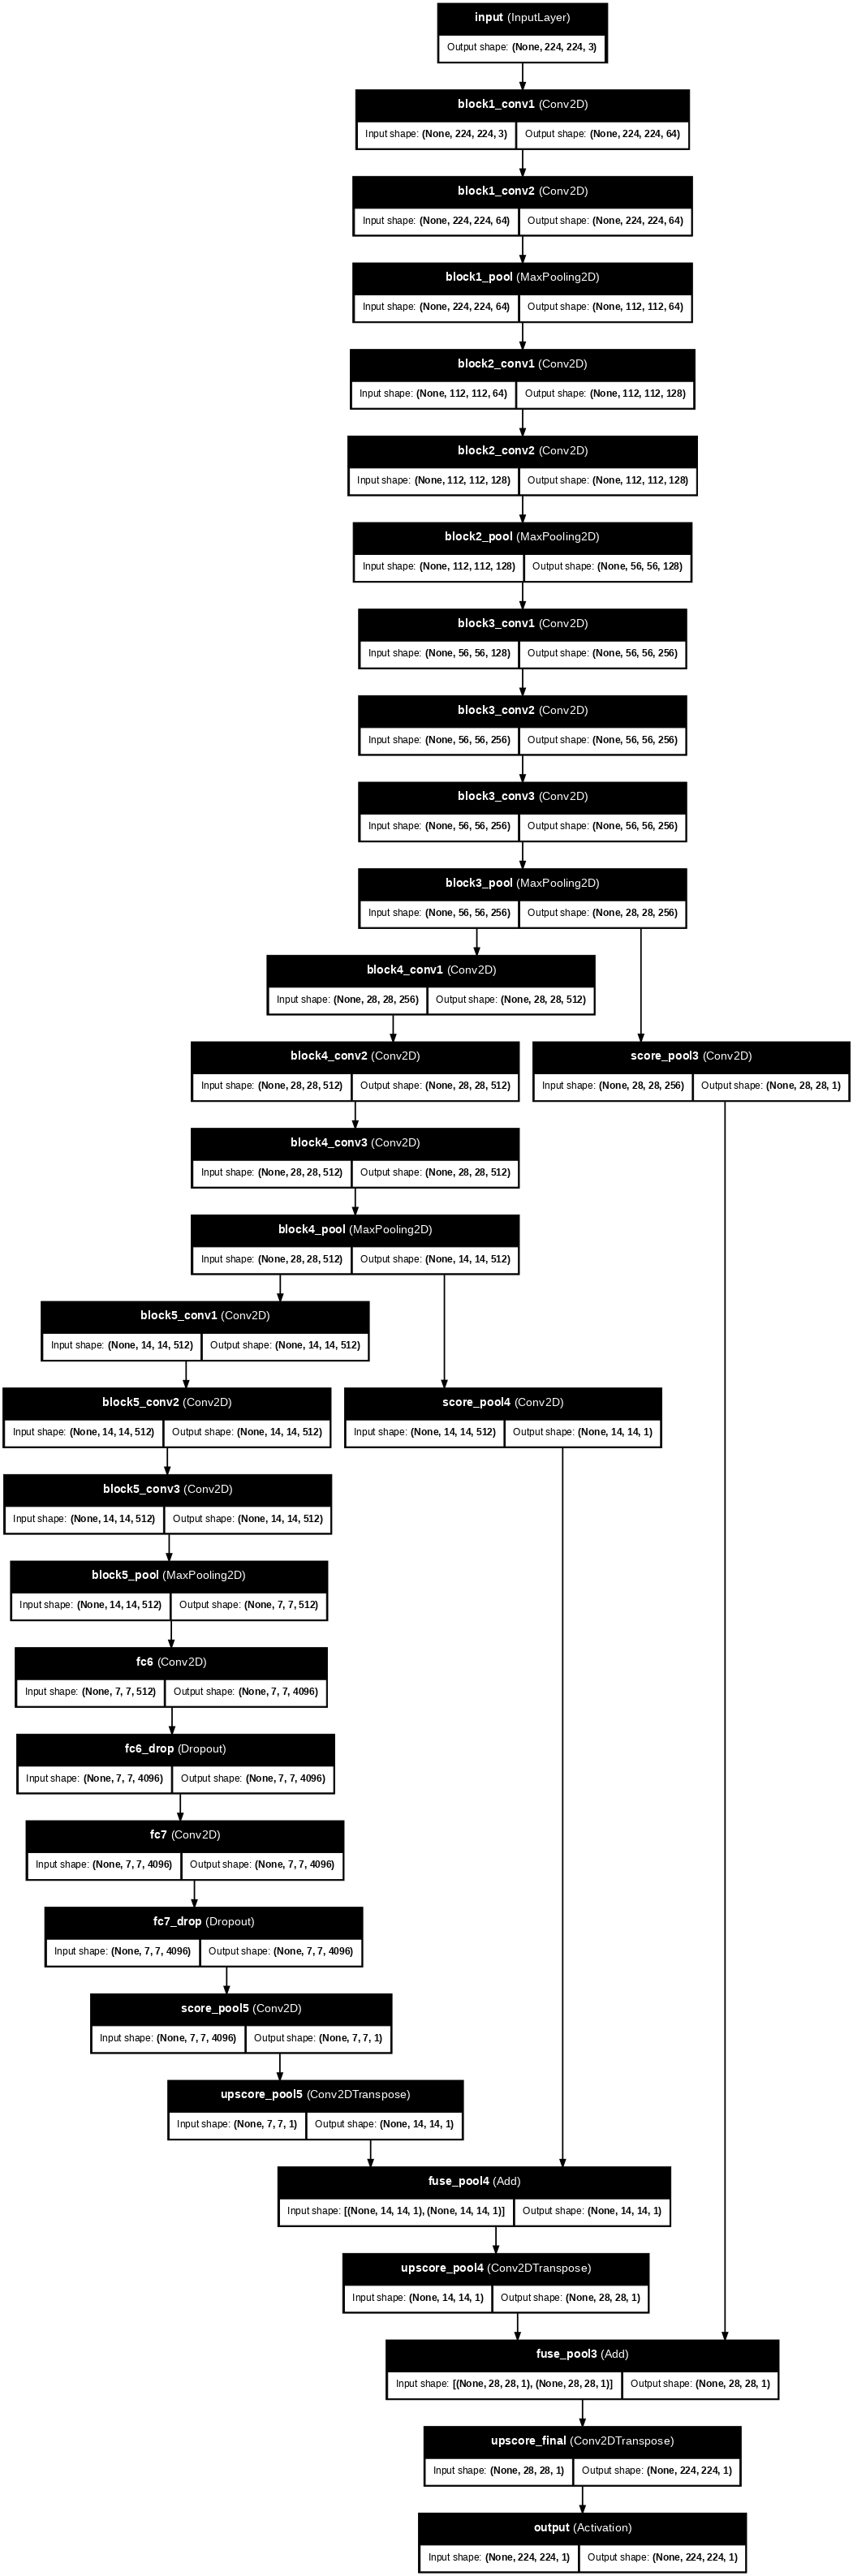

In [10]:
model.summary()

tf.keras.utils.plot_model(
    model,
    to_file='fcn8s_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=64
)

## 10. Callbacks  (EarlyStopping disabled — full epochs as instructed)

In [11]:
def create_mask(pred):
    return tf.math.round(pred)


def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            pred_mask = create_mask(preds[i])
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(imgs[i].numpy());            axes[0].set_title('Input MRI')
            axes[1].imshow(masks[i].numpy()[..., 0], cmap='gray'); axes[1].set_title('Ground Truth')
            axes[2].imshow(pred_mask.numpy()[..., 0], cmap='gray'); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout()
            plt.show()


class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')


logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_fcn8s.keras', verbose=1, save_best_only=True,
                               monitor='val_iou_score', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                                 min_lr=1e-7, verbose=1),
    # EarlyStopping intentionally removed — train for the full EPOCHS as instructed
]

print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


I0000 00:00:1781962143.642211     132 service.cc:152] XLA service 0x79936000d250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781962143.642246     132 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781962143.829469     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781962151.264605     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


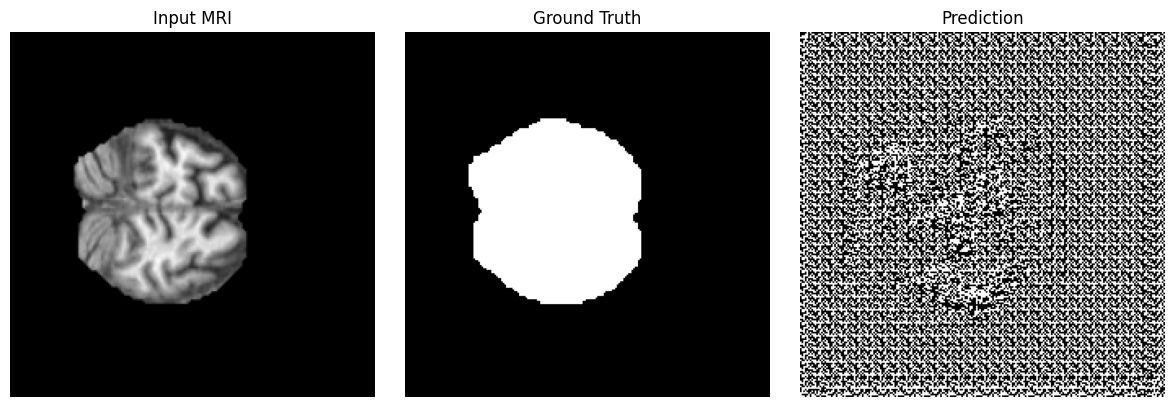

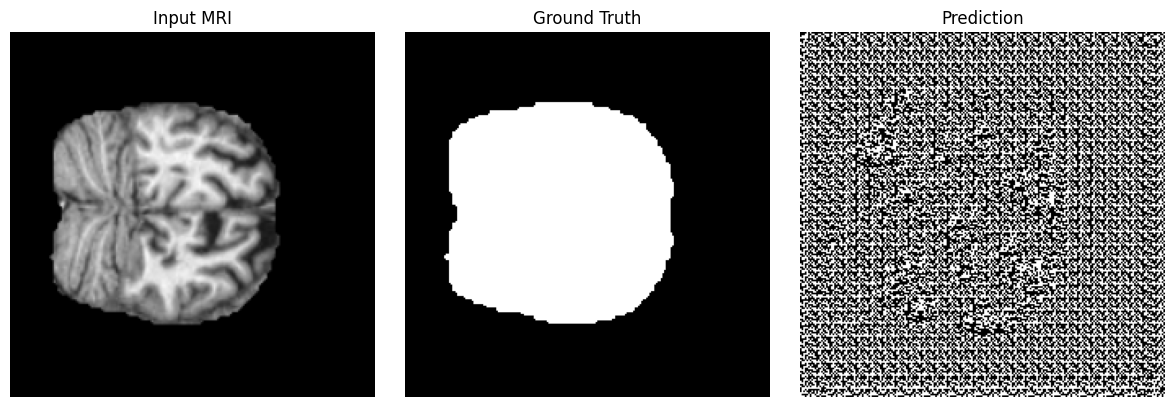

In [12]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 351
Validation steps : 62
Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - dice_coefficient: 0.3768 - iou_score: 0.2375 - loss: 1.3792 - pixel_accuracy: 0.5475 - precision_smooth: 0.3248 - recall_smooth: 0.4988
Epoch 1: val_iou_score improved from None to 0.46978, saving model to best_model_fcn8s.keras

Epoch 1: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 203ms/step - dice_coefficient: 0.4245 - iou_score: 0.2780 - loss: 1.2301 - pixel_accuracy: 0.6306 - precision_smooth: 0.3665 - recall_smooth: 0.5543 - val_dice_coefficient: 0.6388 - val_iou_score: 0.4698 - val_loss: 0.7306 - val_pixel_accuracy: 0.8516 - val_precision_smooth: 0.5635 - val_recall_smooth: 0.7398 - learning_rate: 1.0000e-04
Epoch 2/100
  1/351 ━━━━━━━━━━━━━━━━━━━━ 50:31 9s/step - dice_coefficient: 0.4520 - iou_score: 0.2920 - loss: 0.8653 - pixel_accuracy: 0.8949 - precision_smooth: 0.3155 - recall_smooth: 0.7970
Epoch 2: val_iou_score improved from 0.46978 t

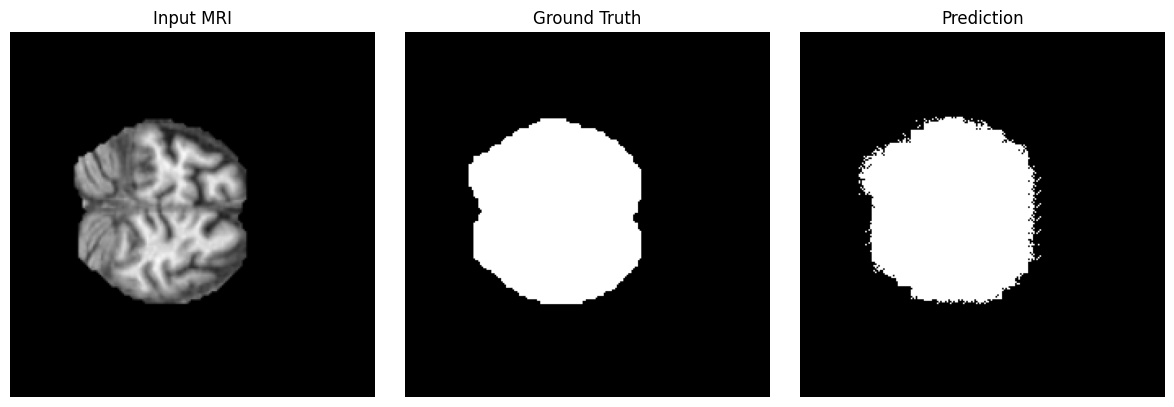

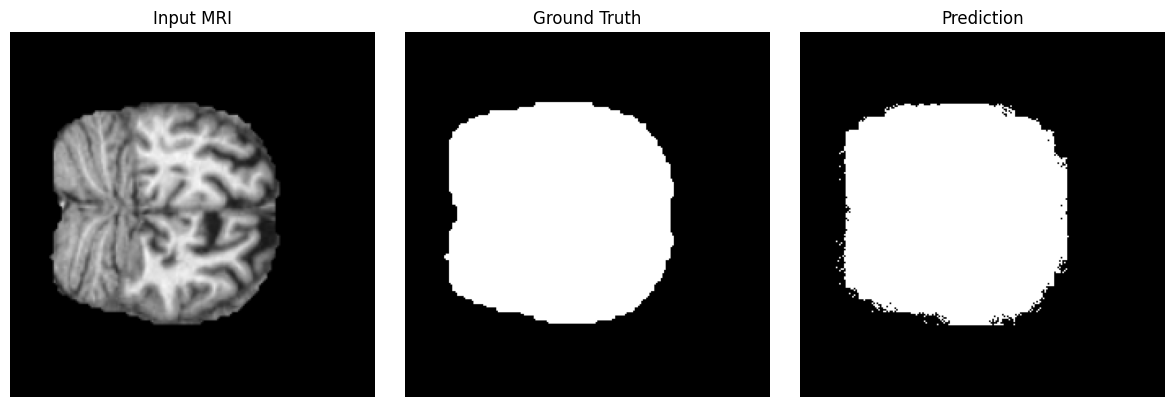

Prediction after epoch 10


Epoch 10: val_iou_score improved from 0.93105 to 0.93110, saving model to best_model_fcn8s.keras

Epoch 10: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - dice_coefficient: 0.9479 - iou_score: 0.9009 - loss: 0.0756 - pixel_accuracy: 0.9906 - precision_smooth: 0.9424 - recall_smooth: 0.9535 - val_dice_coefficient: 0.9643 - val_iou_score: 0.9311 - val_loss: 0.0761 - val_pixel_accuracy: 0.9838 - val_precision_smooth: 0.9607 - val_recall_smooth: 0.9680 - learning_rate: 1.0000e-04
Epoch 11/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - dice_coefficient: 0.9624 - iou_score: 0.9276 - loss: 0.0767 - pixel_accuracy: 0.9843 - precision_smooth: 0.9602 - recall_smooth: 0.9646
Epoch 11: val_iou_score improved from 0.93110 to 0.94139, saving model to best_model_fcn8s.keras

Epoch 11: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 201ms/step - dice_coefficient: 0.9636 - iou_score: 0.9300 - lo

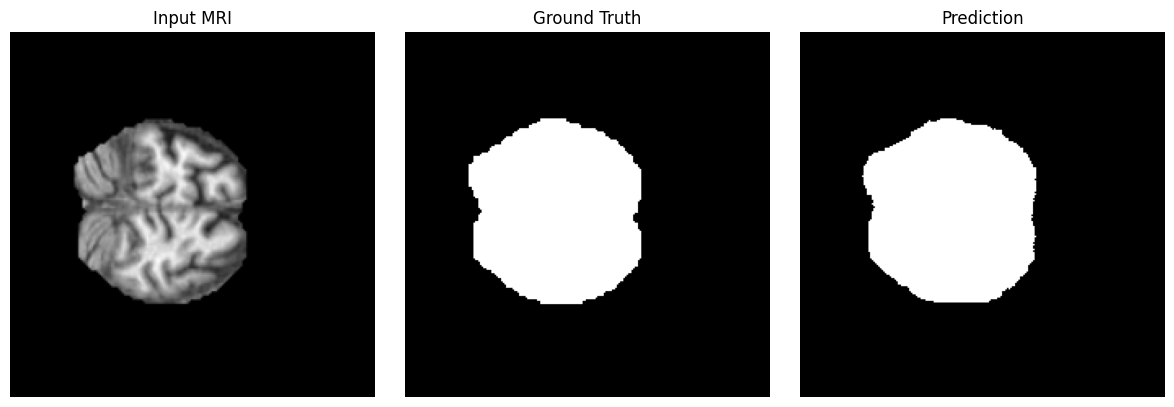

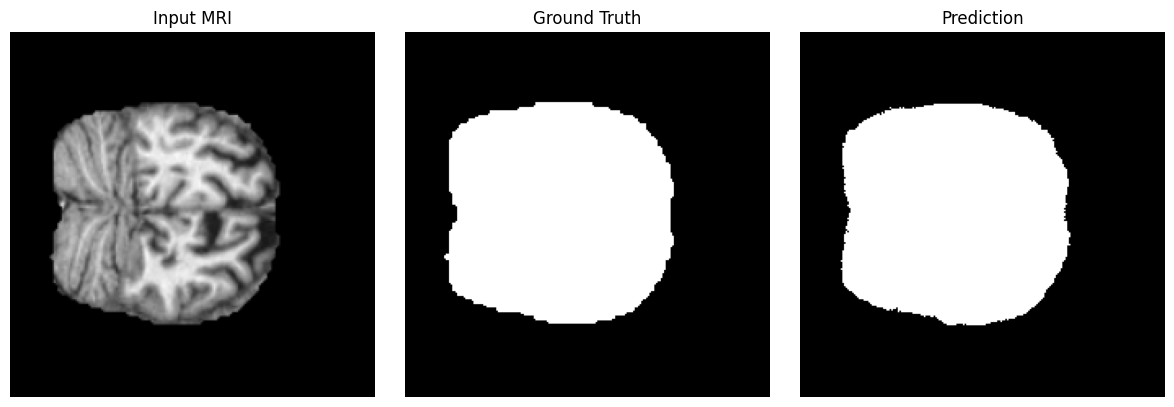

Prediction after epoch 20


Epoch 20: val_iou_score improved from 0.96200 to 0.96203, saving model to best_model_fcn8s.keras

Epoch 20: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - dice_coefficient: 0.9719 - iou_score: 0.9454 - loss: 0.0396 - pixel_accuracy: 0.9952 - precision_smooth: 0.9732 - recall_smooth: 0.9707 - val_dice_coefficient: 0.9806 - val_iou_score: 0.9620 - val_loss: 0.0398 - val_pixel_accuracy: 0.9916 - val_precision_smooth: 0.9793 - val_recall_smooth: 0.9820 - learning_rate: 1.0000e-04
Epoch 21/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - dice_coefficient: 0.9790 - iou_score: 0.9589 - loss: 0.0418 - pixel_accuracy: 0.9914 - precision_smooth: 0.9785 - recall_smooth: 0.9795
Epoch 21: val_iou_score improved from 0.96203 to 0.96460, saving model to best_model_fcn8s.keras

Epoch 21: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 110s 200ms/step - dice_coefficient: 0.9791 - iou_score: 0.9592 - l

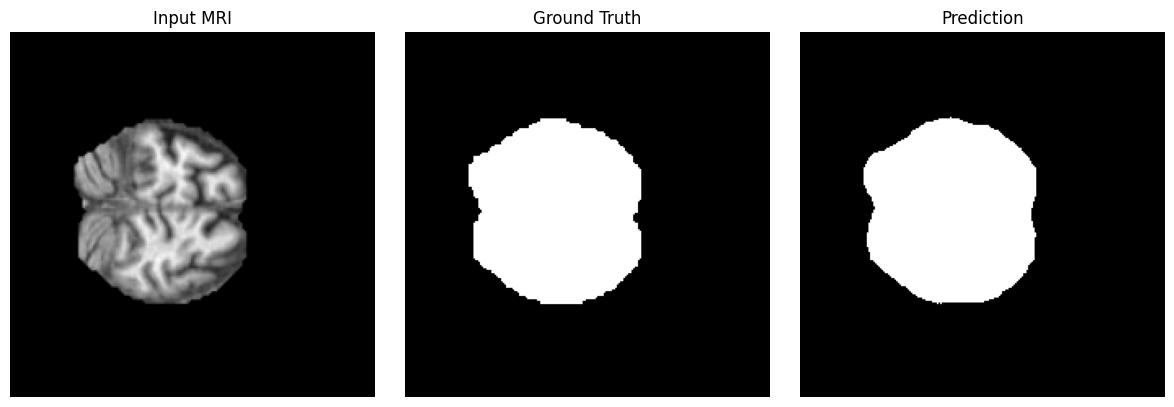

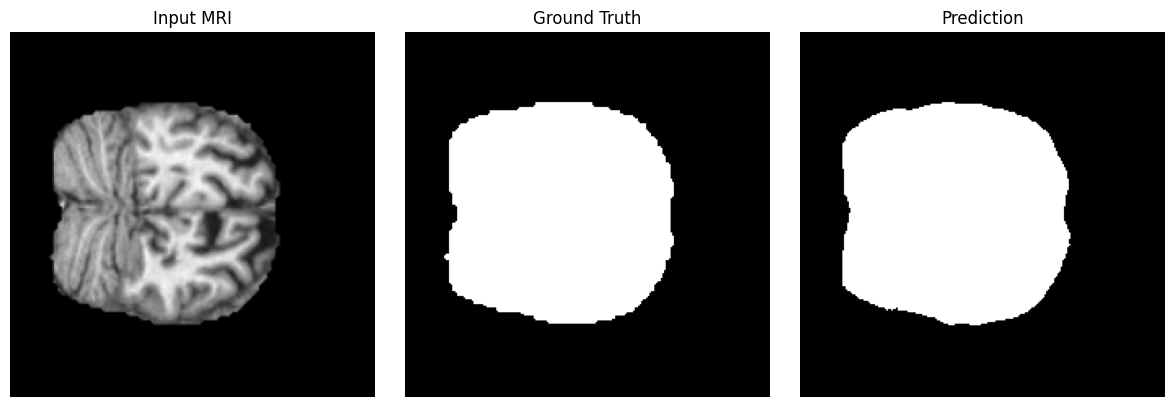

Prediction after epoch 30


Epoch 30: val_iou_score improved from 0.97107 to 0.97107, saving model to best_model_fcn8s.keras

Epoch 30: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - dice_coefficient: 0.9783 - iou_score: 0.9574 - loss: 0.0313 - pixel_accuracy: 0.9960 - precision_smooth: 0.9766 - recall_smooth: 0.9799 - val_dice_coefficient: 0.9853 - val_iou_score: 0.9711 - val_loss: 0.0310 - val_pixel_accuracy: 0.9933 - val_precision_smooth: 0.9843 - val_recall_smooth: 0.9863 - learning_rate: 1.0000e-04
Epoch 31/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - dice_coefficient: 0.9839 - iou_score: 0.9683 - loss: 0.0329 - pixel_accuracy: 0.9931 - precision_smooth: 0.9837 - recall_smooth: 0.9840
Epoch 31: val_iou_score improved from 0.97107 to 0.97207, saving model to best_model_fcn8s.keras

Epoch 31: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 199ms/step - dice_coefficient: 0.9838 - iou_score: 0.9682 - lo

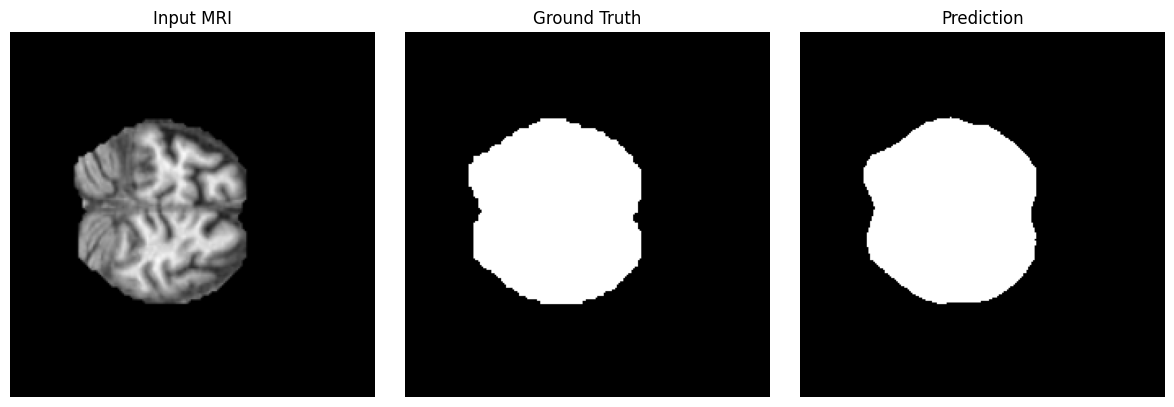

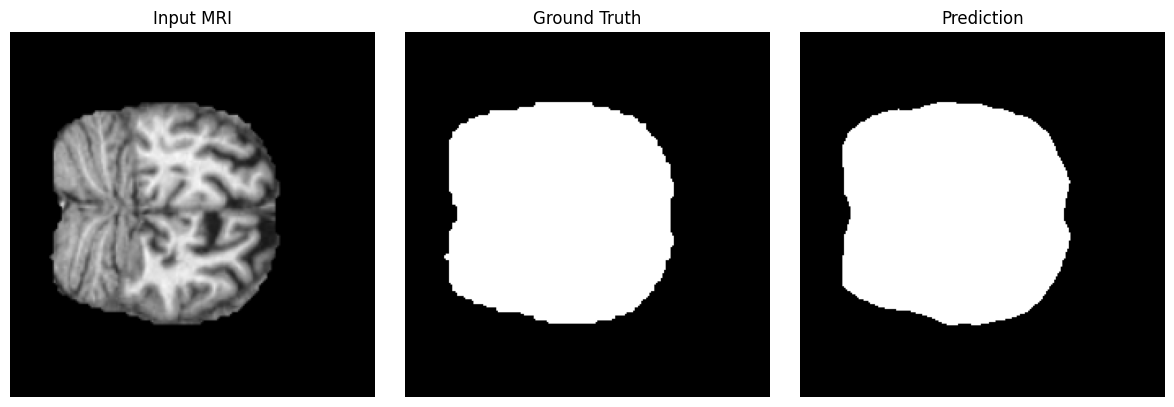

Prediction after epoch 40


Epoch 40: val_iou_score improved from 0.97521 to 0.97522, saving model to best_model_fcn8s.keras

Epoch 40: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - dice_coefficient: 0.9808 - iou_score: 0.9623 - loss: 0.0282 - pixel_accuracy: 0.9963 - precision_smooth: 0.9792 - recall_smooth: 0.9825 - val_dice_coefficient: 0.9875 - val_iou_score: 0.9752 - val_loss: 0.0271 - val_pixel_accuracy: 0.9941 - val_precision_smooth: 0.9867 - val_recall_smooth: 0.9883 - learning_rate: 1.0000e-04
Epoch 41/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - dice_coefficient: 0.9861 - iou_score: 0.9726 - loss: 0.0290 - pixel_accuracy: 0.9939 - precision_smooth: 0.9860 - recall_smooth: 0.9862
Epoch 41: val_iou_score improved from 0.97522 to 0.97569, saving model to best_model_fcn8s.keras

Epoch 41: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 199ms/step - dice_coefficient: 0.9860 - iou_score: 0.9725 - lo

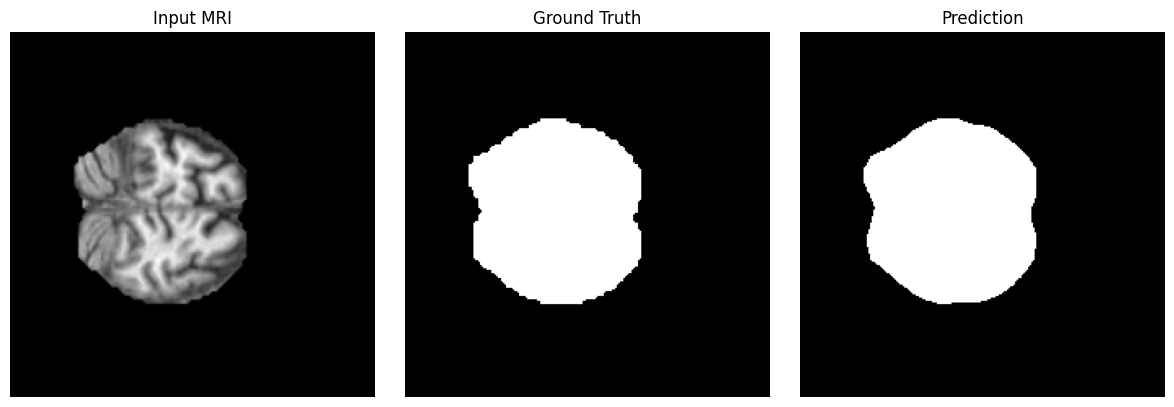

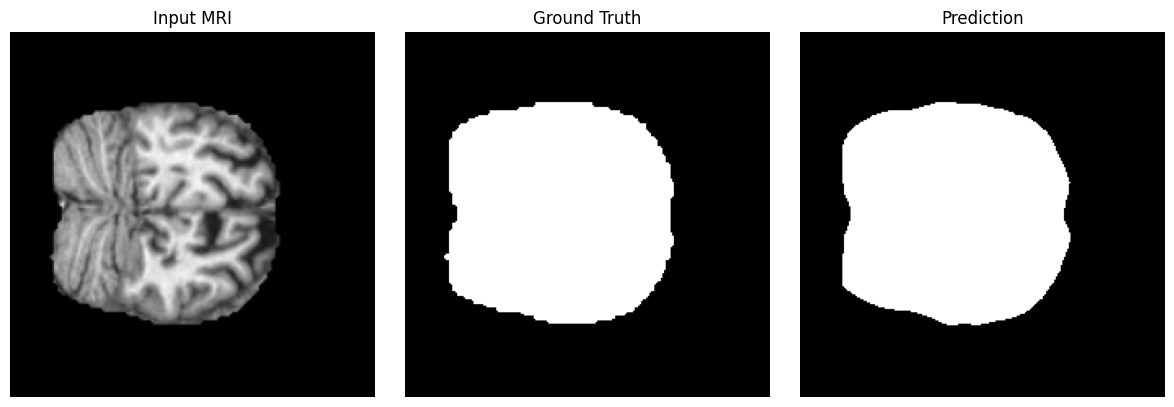

Prediction after epoch 50


Epoch 50: val_iou_score improved from 0.97724 to 0.97725, saving model to best_model_fcn8s.keras

Epoch 50: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - dice_coefficient: 0.9818 - iou_score: 0.9643 - loss: 0.0272 - pixel_accuracy: 0.9964 - precision_smooth: 0.9806 - recall_smooth: 0.9830 - val_dice_coefficient: 0.9885 - val_iou_score: 0.9773 - val_loss: 0.0252 - val_pixel_accuracy: 0.9945 - val_precision_smooth: 0.9880 - val_recall_smooth: 0.9890 - learning_rate: 1.0000e-04
Epoch 51/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - dice_coefficient: 0.9873 - iou_score: 0.9749 - loss: 0.0268 - pixel_accuracy: 0.9943 - precision_smooth: 0.9872 - recall_smooth: 0.9874
Epoch 51: val_iou_score improved from 0.97725 to 0.97759, saving model to best_model_fcn8s.keras

Epoch 51: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 110s 200ms/step - dice_coefficient: 0.9872 - iou_score: 0.9748 - l

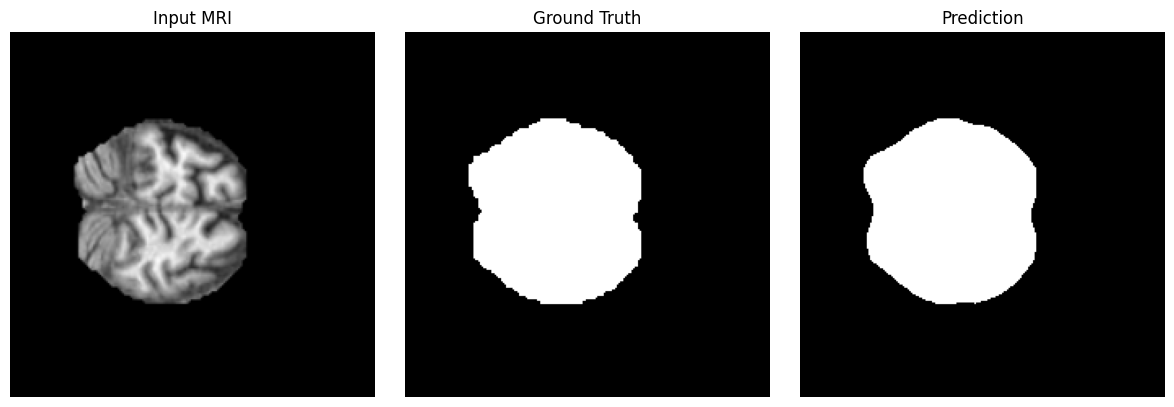

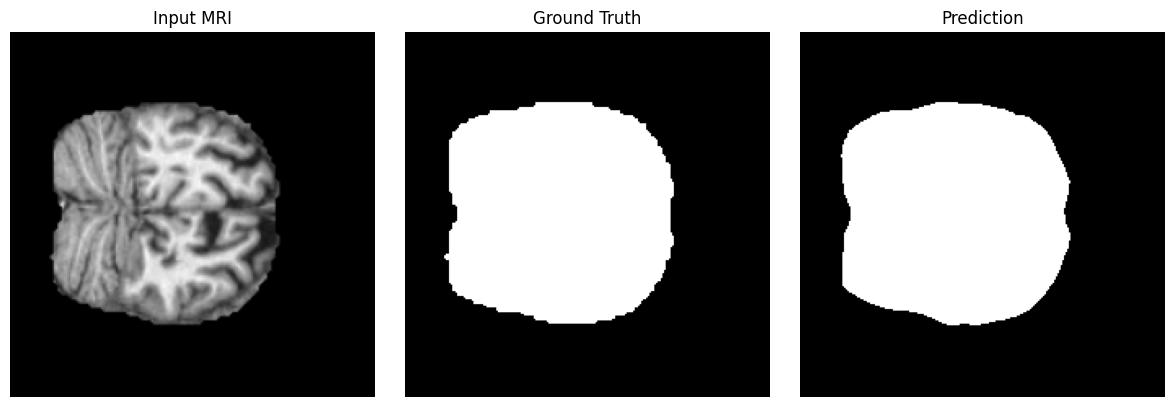

Prediction after epoch 60


Epoch 60: val_iou_score improved from 0.97847 to 0.97849, saving model to best_model_fcn8s.keras

Epoch 60: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - dice_coefficient: 0.9826 - iou_score: 0.9658 - loss: 0.0260 - pixel_accuracy: 0.9965 - precision_smooth: 0.9801 - recall_smooth: 0.9850 - val_dice_coefficient: 0.9891 - val_iou_score: 0.9785 - val_loss: 0.0242 - val_pixel_accuracy: 0.9947 - val_precision_smooth: 0.9879 - val_recall_smooth: 0.9904 - learning_rate: 1.0000e-04
Epoch 61/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - dice_coefficient: 0.9879 - iou_score: 0.9762 - loss: 0.0256 - pixel_accuracy: 0.9946 - precision_smooth: 0.9879 - recall_smooth: 0.9880
Epoch 61: val_iou_score improved from 0.97849 to 0.97866, saving model to best_model_fcn8s.keras

Epoch 61: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 199ms/step - dice_coefficient: 0.9878 - iou_score: 0.9760 - lo

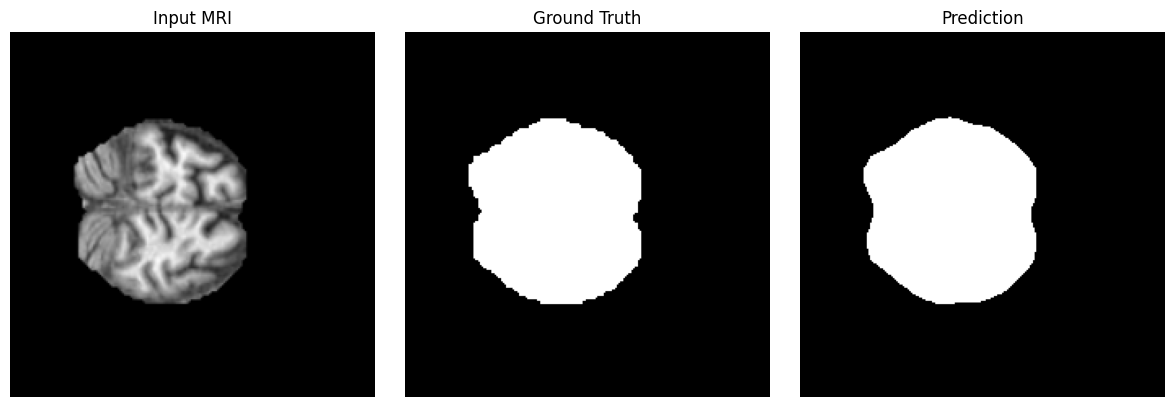

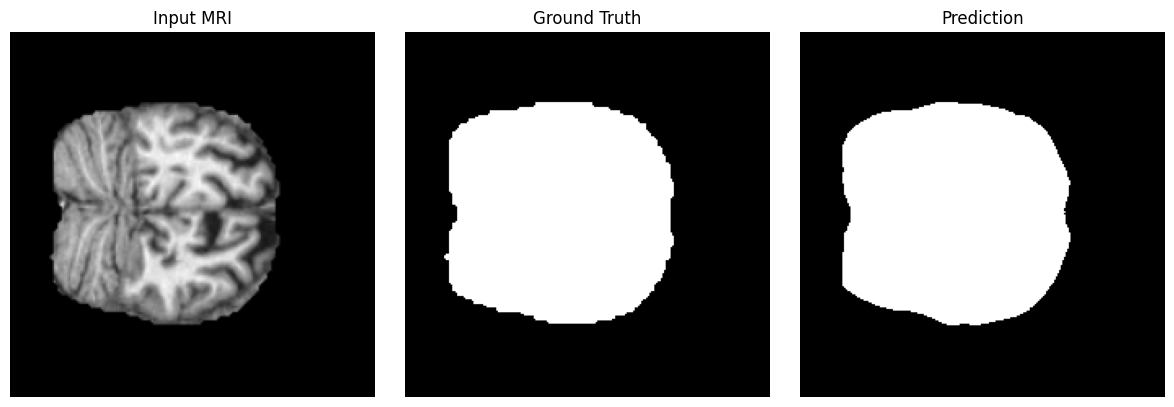

Prediction after epoch 70


Epoch 70: val_iou_score did not improve from 0.97921
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - dice_coefficient: 0.9831 - iou_score: 0.9668 - loss: 0.0256 - pixel_accuracy: 0.9966 - precision_smooth: 0.9817 - recall_smooth: 0.9845 - val_dice_coefficient: 0.9895 - val_iou_score: 0.9792 - val_loss: 0.0234 - val_pixel_accuracy: 0.9949 - val_precision_smooth: 0.9891 - val_recall_smooth: 0.9899 - learning_rate: 1.0000e-04
Epoch 71/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - dice_coefficient: 0.9883 - iou_score: 0.9769 - loss: 0.0249 - pixel_accuracy: 0.9947 - precision_smooth: 0.9883 - recall_smooth: 0.9884
Epoch 71: val_iou_score improved from 0.97921 to 0.97935, saving model to best_model_fcn8s.keras

Epoch 71: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 69s 198ms/step - dice_coefficient: 0.9882 - iou_score: 0.9767 - loss: 0.0250 - pixel_accuracy: 0.9947 - precision_smooth: 0.9881 - recall_smooth: 0.9883 - val_dice_coeff

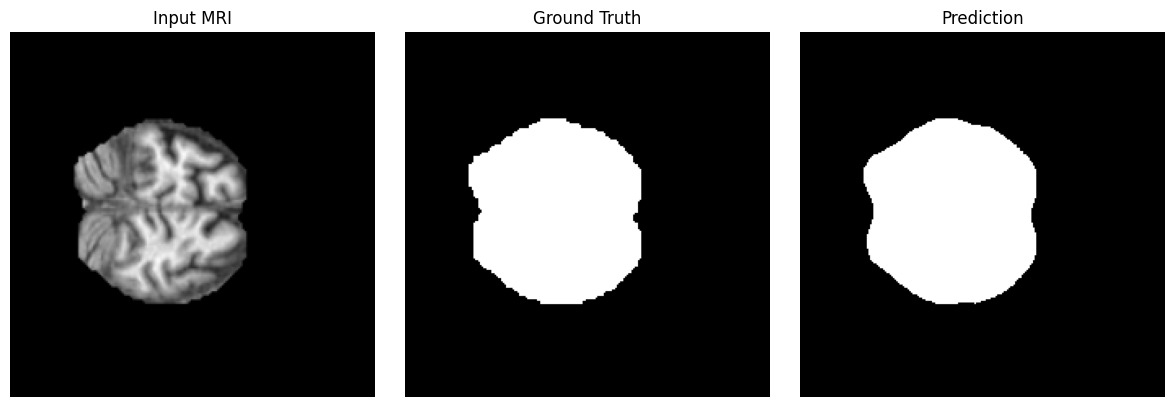

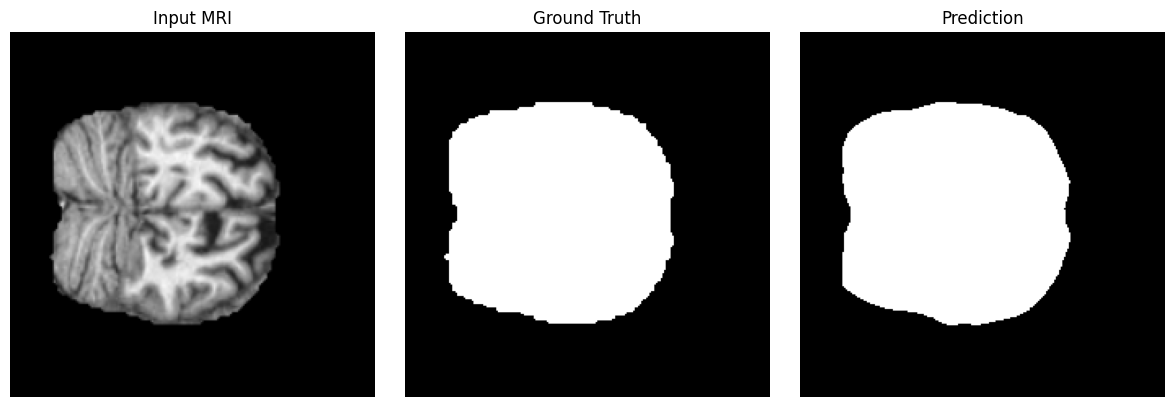

Prediction after epoch 80


Epoch 80: val_iou_score improved from 0.97966 to 0.97967, saving model to best_model_fcn8s.keras

Epoch 80: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - dice_coefficient: 0.9835 - iou_score: 0.9675 - loss: 0.0249 - pixel_accuracy: 0.9967 - precision_smooth: 0.9830 - recall_smooth: 0.9839 - val_dice_coefficient: 0.9897 - val_iou_score: 0.9797 - val_loss: 0.0229 - val_pixel_accuracy: 0.9950 - val_precision_smooth: 0.9888 - val_recall_smooth: 0.9906 - learning_rate: 5.0000e-05
Epoch 81/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - dice_coefficient: 0.9886 - iou_score: 0.9775 - loss: 0.0242 - pixel_accuracy: 0.9949 - precision_smooth: 0.9885 - recall_smooth: 0.9887
Epoch 81: val_iou_score improved from 0.97967 to 0.97974, saving model to best_model_fcn8s.keras

Epoch 81: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 199ms/step - dice_coefficient: 0.9885 - iou_score: 0.9773 - lo

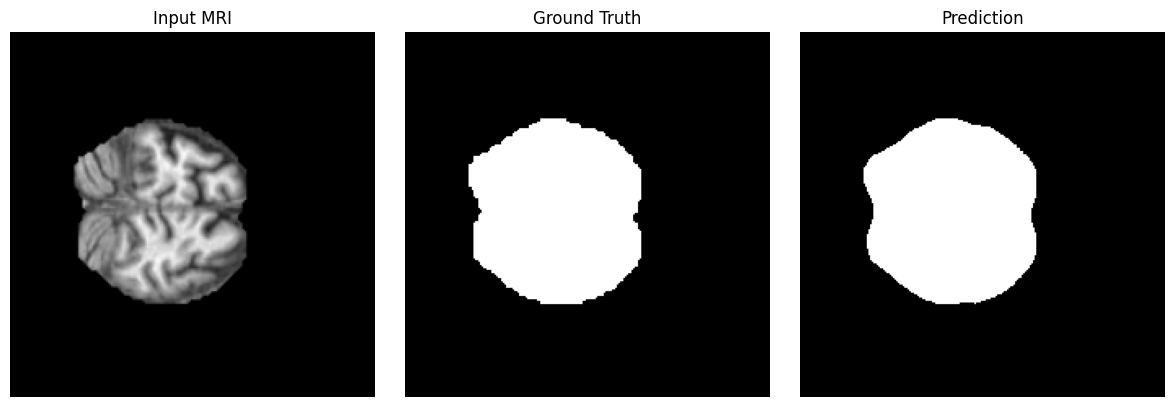

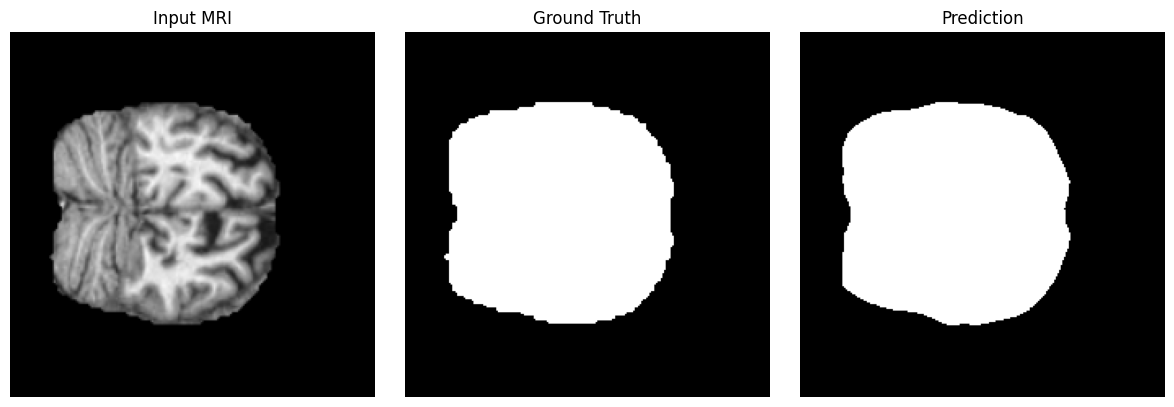

Prediction after epoch 90


Epoch 90: val_iou_score did not improve from 0.97992

Epoch 90: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - dice_coefficient: 0.9837 - iou_score: 0.9679 - loss: 0.0244 - pixel_accuracy: 0.9967 - precision_smooth: 0.9829 - recall_smooth: 0.9844 - val_dice_coefficient: 0.9899 - val_iou_score: 0.9799 - val_loss: 0.0227 - val_pixel_accuracy: 0.9950 - val_precision_smooth: 0.9889 - val_recall_smooth: 0.9908 - learning_rate: 5.0000e-05
Epoch 91/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - dice_coefficient: 0.9887 - iou_score: 0.9778 - loss: 0.0239 - pixel_accuracy: 0.9950 - precision_smooth: 0.9886 - recall_smooth: 0.9889
Epoch 91: val_iou_score improved from 0.97992 to 0.98002, saving model to best_model_fcn8s.keras

Epoch 91: finished saving model to best_model_fcn8s.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 69s 198ms/step - dice_coefficient: 0.9886 - iou_score: 0.9776 - loss: 0.0241 - pixel_accura

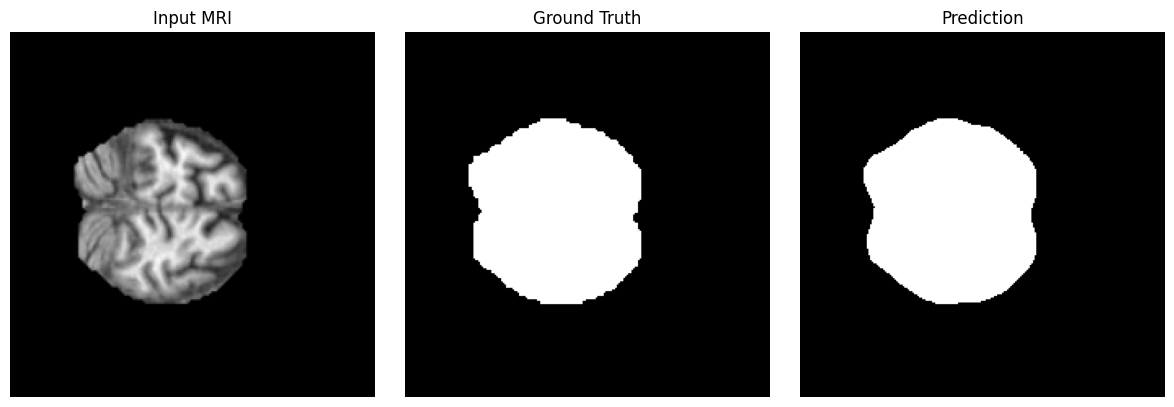

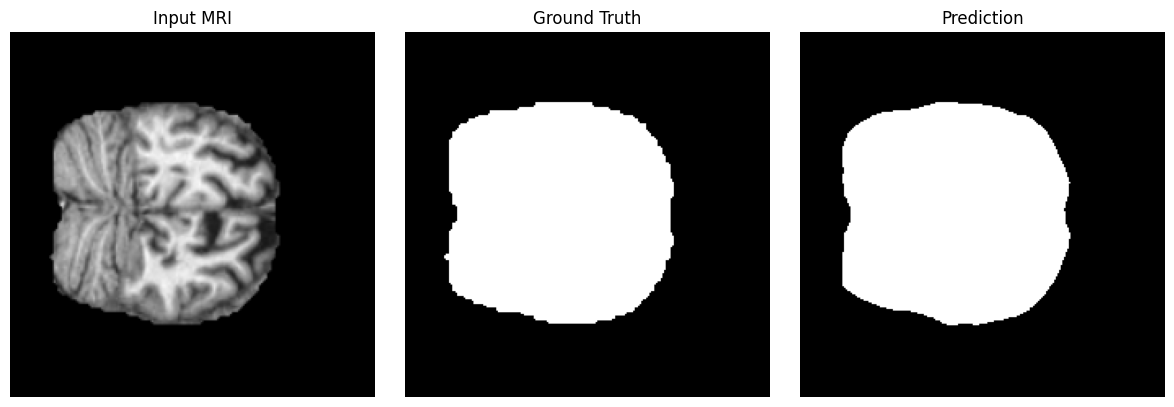

Prediction after epoch 100


Epoch 100: val_iou_score did not improve from 0.98016
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - dice_coefficient: 0.9834 - iou_score: 0.9673 - loss: 0.0251 - pixel_accuracy: 0.9966 - precision_smooth: 0.9847 - recall_smooth: 0.9821 - val_dice_coefficient: 0.9900 - val_iou_score: 0.9802 - val_loss: 0.0224 - val_pixel_accuracy: 0.9951 - val_precision_smooth: 0.9894 - val_recall_smooth: 0.9906 - learning_rate: 1.2500e-05

Training time: 87.1 min


In [13]:
steps_per_epoch  = len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE
validation_steps = len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed/60:.1f} min')

## 13. Training Graphs

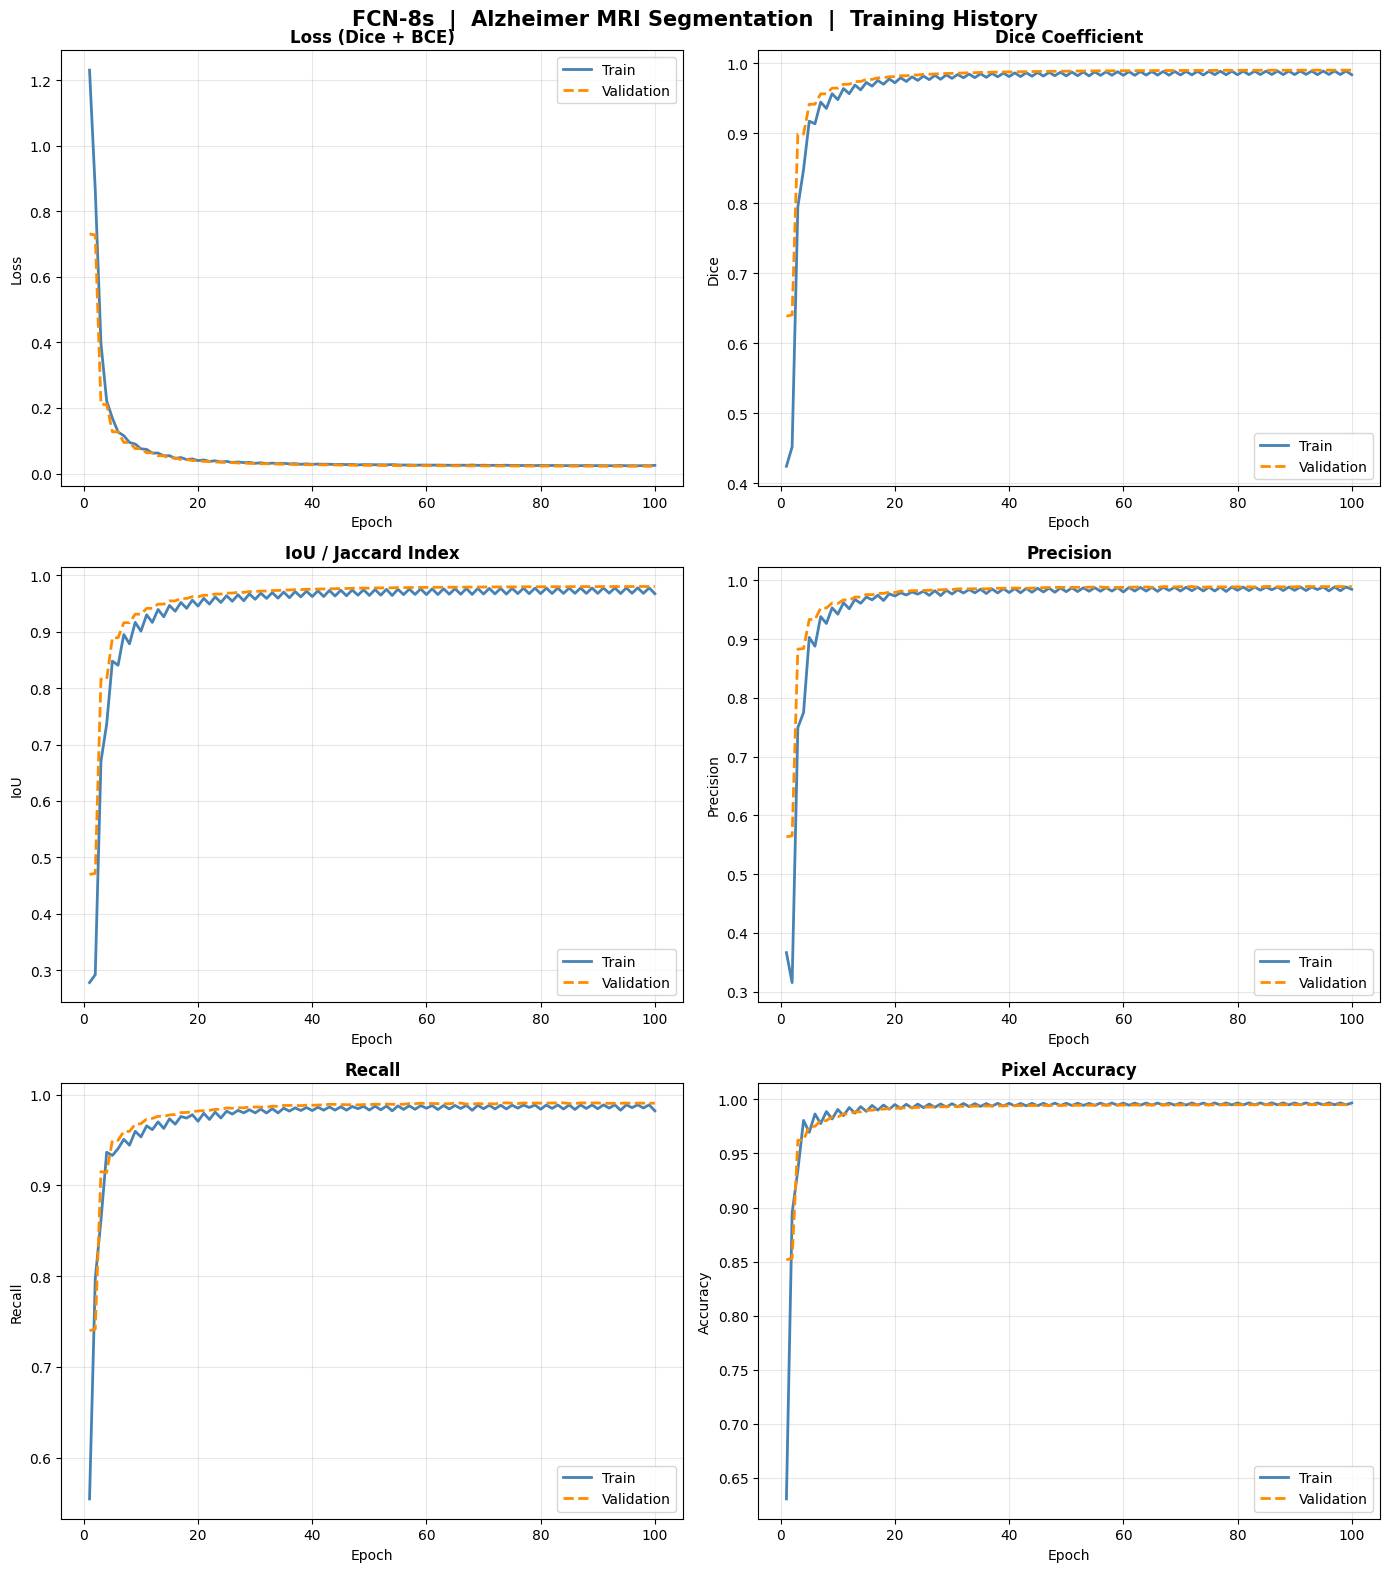

Plot saved → training_history_fcn8s.png


In [14]:
H = history.history

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('FCN-8s  |  Alzheimer MRI Segmentation  |  Training History',
             fontsize=15, fontweight='bold', y=0.98)

plot_specs = [
    ('loss',             'val_loss',             'Loss (Dice + BCE)',      'Loss',     'upper right'),
    ('dice_coefficient', 'val_dice_coefficient', 'Dice Coefficient',       'Dice',     'lower right'),
    ('iou_score',        'val_iou_score',        'IoU / Jaccard Index',    'IoU',      'lower right'),
    ('precision_smooth', 'val_precision_smooth', 'Precision',              'Precision','lower right'),
    ('recall_smooth',    'val_recall_smooth',    'Recall',                 'Recall',   'lower right'),
    ('pixel_accuracy',   'val_pixel_accuracy',   'Pixel Accuracy',         'Accuracy', 'lower right'),
]

for ax, (train_key, val_key, title, ylabel, loc) in zip(axes.flatten(), plot_specs):
    epochs_range = range(1, len(H[train_key]) + 1)
    ax.plot(epochs_range, H[train_key], label='Train',      color='steelblue',   linewidth=2)
    ax.plot(epochs_range, H[val_key],   label='Validation', color='darkorange',  linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(loc=loc, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_fcn8s.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → training_history_fcn8s.png')

## 14. Best & Average Metrics Table

In [15]:
metric_spec = [
    ('Loss',           'loss',             'min'),
    ('Dice',           'dice_coefficient', 'max'),
    ('IoU (Jaccard)',  'iou_score',        'max'),
    ('Precision',      'precision_smooth', 'max'),
    ('Recall',         'recall_smooth',    'max'),
    ('Pixel Accuracy', 'pixel_accuracy',   'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key],          dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({
        'Metric':     disp,
        'Train Best': pick(tr), 'Train Avg': tr.mean(),
        'Val Best':   pick(va), 'Val Avg':   va.mean(),
    })

def f1_curve(p, r):
    p = np.asarray(p, dtype=np.float64); r = np.asarray(r, dtype=np.float64)
    return 2.0 * p * r / (p + r + 1e-7)

tr_f1 = f1_curve(H['precision_smooth'],     H['recall_smooth'])
va_f1 = f1_curve(H['val_precision_smooth'], H['val_recall_smooth'])
rows.append({'Metric': 'F1-Score',
             'Train Best': tr_f1.max(), 'Train Avg': tr_f1.mean(),
             'Val Best':   va_f1.max(), 'Val Avg':   va_f1.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  FCN-8s  |  OASIS disc1+disc2')
print('=' * 68)
print(report.to_string())
print('=' * 68)

best_epoch_iou  = int(np.argmax(H['val_iou_score']))  + 1
best_epoch_dice = int(np.argmax(H['val_dice_coefficient'])) + 1
print(f'\nBest Val IoU : {max(H["val_iou_score"]):.4f}  (epoch {best_epoch_iou})')
print(f'Best Val Dice: {max(H["val_dice_coefficient"]):.4f}  (epoch {best_epoch_dice})')

# Overfitting check — gap between train and val at final epoch
final_gap_iou  = H['val_iou_score'][-1]  - H['iou_score'][-1]
final_gap_dice = H['val_dice_coefficient'][-1] - H['dice_coefficient'][-1]
print(f'\nFinal-epoch Val-Train gap → IoU: {final_gap_iou:+.4f}, Dice: {final_gap_dice:+.4f}')
print('(Large positive gap can indicate train metrics still catching up;')
print(' large negative gap with val dropping while train keeps rising = overfitting.)')

report

   BEST & AVERAGE METRICS  —  FCN-8s  |  OASIS disc1+disc2
                Train Best  Train Avg  Val Best  Val Avg
Metric                                                  
Loss                0.0239     0.0611    0.0224   0.0502
Dice                0.9887     0.9655    0.9900   0.9762
IoU (Jaccard)       0.9777     0.9416    0.9802   0.9573
Precision           0.9887     0.9611    0.9895   0.9733
Recall              0.9888     0.9732    0.9910   0.9797
Pixel Accuracy      0.9968     0.9887    0.9951   0.9896
F1-Score            0.9887     0.9658    0.9900   0.9763

Best Val IoU : 0.9802  (epoch 99)
Best Val Dice: 0.9900  (epoch 99)

Final-epoch Val-Train gap → IoU: +0.0128, Dice: +0.0066
(Large positive gap can indicate train metrics still catching up;
 large negative gap with val dropping while train keeps rising = overfitting.)


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.0239,0.0611,0.0224,0.0502
Dice,0.9887,0.9655,0.9900,0.9762
IoU (Jaccard),0.9777,0.9416,0.9802,0.9573
Precision,0.9887,0.9611,0.9895,0.9733
Recall,0.9888,0.9732,0.9910,0.9797
Pixel Accuracy,0.9968,0.9887,0.9951,0.9896
F1-Score,0.9887,0.9658,0.9900,0.9763


## 15. Load Best Model & Final Evaluation

In [16]:
best_model = tf.keras.models.load_model(
    'best_model_fcn8s.keras',
    custom_objects={
        'combined_loss':   combined_loss,
        'dice_coefficient': dice_coefficient,
        'iou_score':        iou_score,
        'precision_smooth': precision_smooth,
        'recall_smooth':    recall_smooth,
        'pixel_accuracy':   pixel_accuracy,
    }
)
print('Best model loaded ✓')
best_model.summary()

Best model loaded ✓


Model: "FCN8s"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 373,367,732 (1.39 GB)

 Trainable params: 119,551,014 (456.05 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 239,102,030 (912.10 MB)

In [17]:
print('Evaluating best model on held-out test set...\n')
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict    = dict(zip(best_model.metrics_names, test_results))

label_map = {
    'loss': 'Loss', 'dice_coefficient': 'Dice', 'iou_score': 'IoU (Jaccard)',
    'precision_smooth': 'Precision', 'recall_smooth': 'Recall', 'pixel_accuracy': 'Pixel Accuracy'
}

P = test_dict.get('precision_smooth', 0)
R = test_dict.get('recall_smooth',    0)
f1 = 2 * P * R / (P + R + 1e-7)

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (FCN-8s | OASIS disc1+disc2)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {label_map.get(k, k):20s}: {v:.4f}')
print(f'  {"F1-Score":20s}: {f1:.4f}')
print('=' * 60)

final_df = pd.DataFrame([{
    'Model':      'FCN-8s (OASIS disc1+disc2)',
    'IoU':        round(test_dict.get('iou_score', float('nan')), 4),
    'Dice':       round(test_dict.get('dice_coefficient', float('nan')), 4),
    'Precision':  round(P, 4),
    'Recall':     round(R, 4),
    'Accuracy':   round(test_dict.get('pixel_accuracy', float('nan')), 4),
    'F1':         round(f1, 4),
}]).set_index('Model')
final_df

Evaluating best model on held-out test set...

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - dice_coefficient: 0.9899 - iou_score: 0.9800 - loss: 0.0224 - pixel_accuracy: 0.9951 - precision_smooth: 0.9893 - recall_smooth: 0.9905

  FINAL TEST-SET METRICS  (FCN-8s | OASIS disc1+disc2)
  Loss                : 0.0224
  compile_metrics     : 0.9899
  F1-Score            : 0.0000


,IoU,Dice,Precision,Recall,Accuracy,F1
Model,,,,,,
FCN-8s (OASIS disc1+disc2),NaN,NaN,0,0,NaN,0.0


## 16. Test Predictions Visualization

Test set predictions:


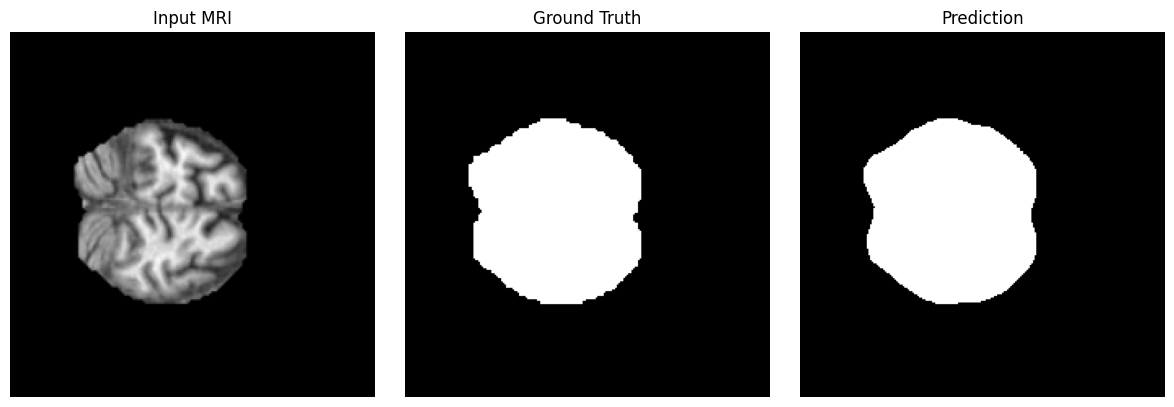

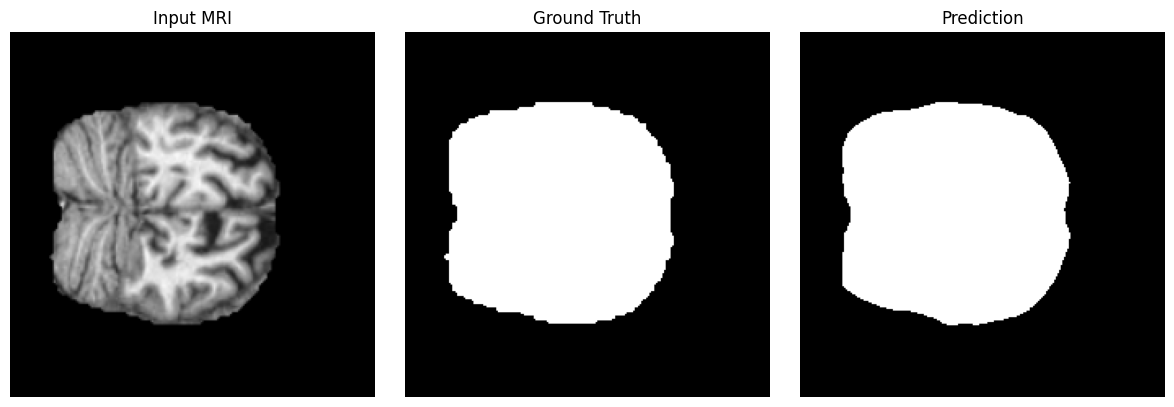

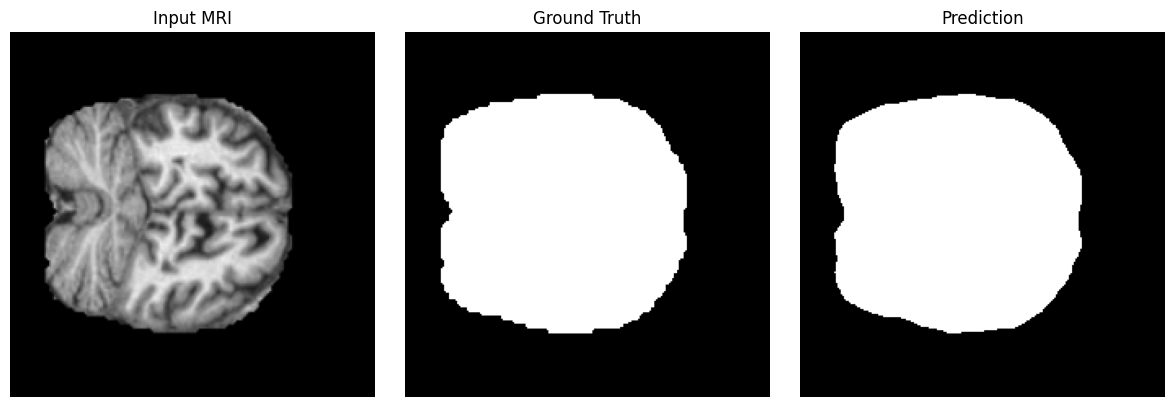

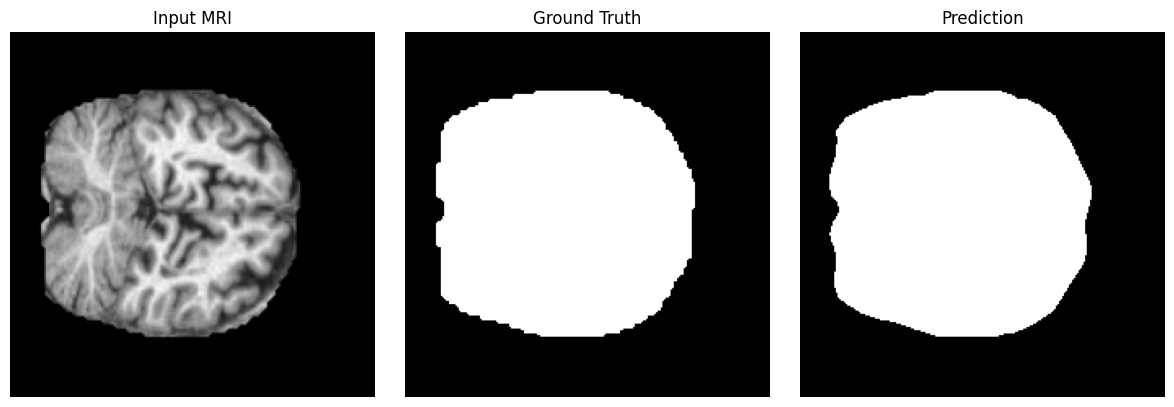

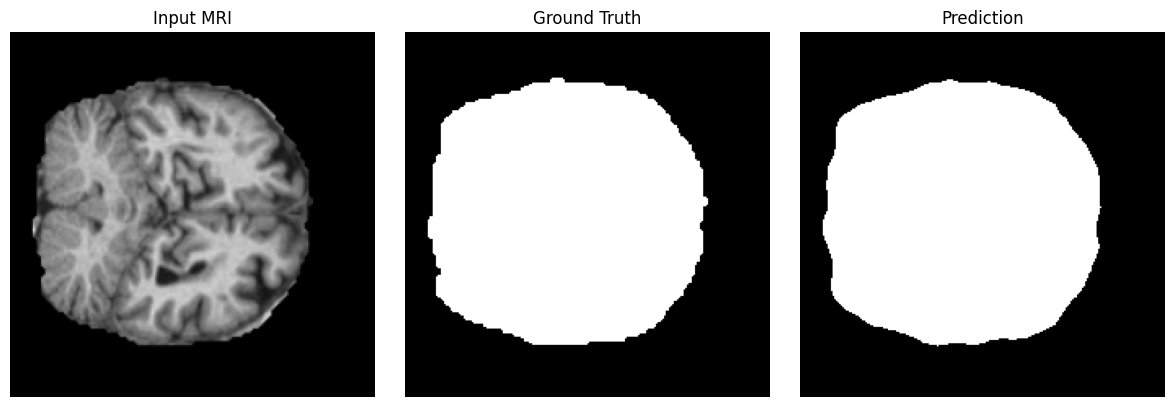

In [18]:
print('Test set predictions:')
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Detailed Prediction Grid

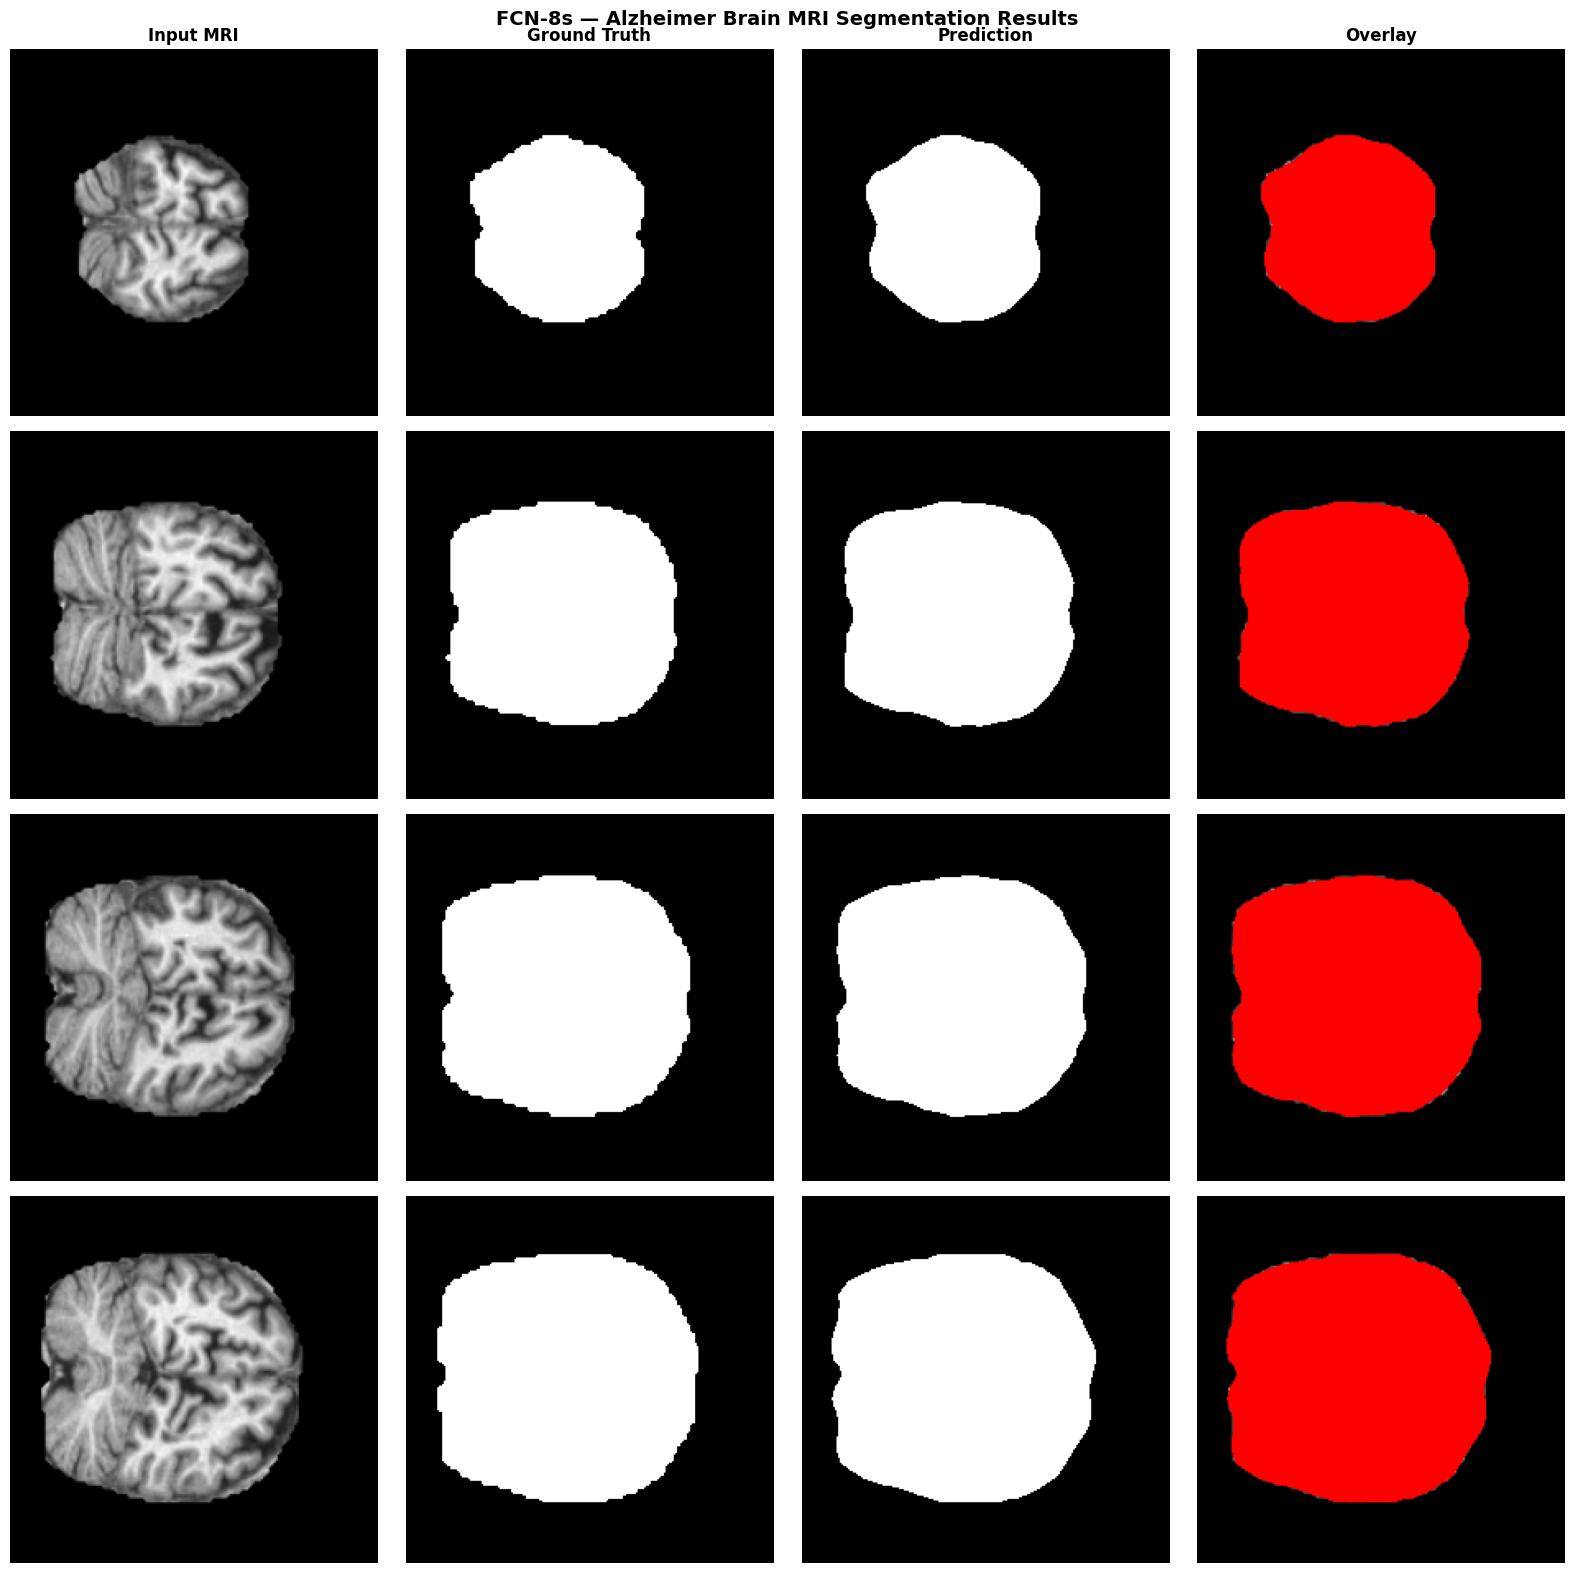

Grid saved → prediction_grid_fcn8s.png


In [19]:
def prediction_grid(dataset, best_model, n_rows=4):
    for imgs, masks in dataset.take(1):
        preds = best_model.predict(imgs[:n_rows], verbose=0)

        fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
        col_titles = ['Input MRI', 'Ground Truth', 'Prediction', 'Overlay']
        for col, t in enumerate(col_titles):
            axes[0, col].set_title(t, fontsize=12, fontweight='bold')

        for row in range(n_rows):
            img   = imgs[row].numpy()
            gt    = masks[row].numpy()[..., 0]
            pred  = create_mask(preds[row]).numpy()[..., 0]

            ov = (img * 255).astype(np.uint8)
            ov[pred > 0.5, 0] = 255
            ov[pred > 0.5, 1] = 0
            ov[pred > 0.5, 2] = 0

            inter = np.sum(gt * pred)
            union = np.sum(gt) + np.sum(pred) - inter
            sample_iou = (inter + 1) / (union + 1)

            axes[row, 0].imshow(img)
            axes[row, 1].imshow(gt,   cmap='gray')
            axes[row, 2].imshow(pred, cmap='gray')
            axes[row, 2].set_xlabel(f'IoU: {sample_iou:.3f}', fontsize=10, color='green')
            axes[row, 3].imshow(ov)

            for col in range(4):
                axes[row, col].axis('off')

        plt.suptitle('FCN-8s — Alzheimer Brain MRI Segmentation Results',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('prediction_grid_fcn8s.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Grid saved → prediction_grid_fcn8s.png')


prediction_grid(test_dataset, best_model, n_rows=4)

## 18. IoU Distribution Plot

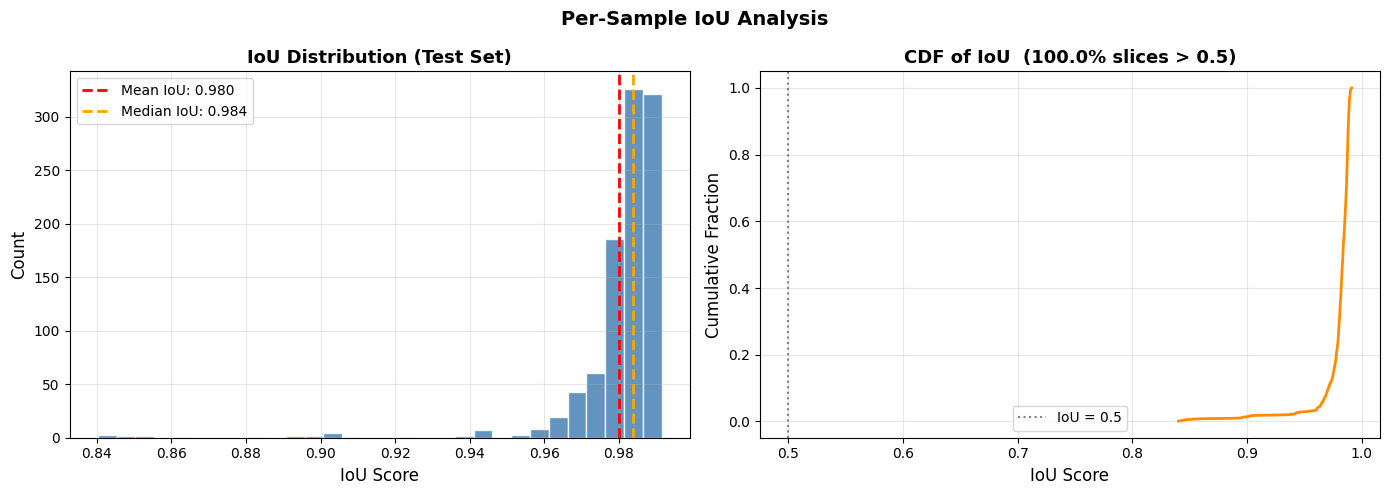


IoU Stats — Mean: 0.9801  |  Std: 0.0164
             Min : 0.8403  |  Max: 0.9914
% slices IoU > 0.5 : 100.0%


In [20]:
iou_scores = []

for imgs, masks in test_dataset:
    preds = best_model.predict(imgs, verbose=0)
    for i in range(len(imgs)):
        gt   = masks[i].numpy()[..., 0]
        pred = (preds[i][..., 0] > 0.5).astype(float)
        inter = np.sum(gt * pred)
        union = np.sum(gt) + np.sum(pred) - inter
        iou_scores.append((inter + 1) / (union + 1))

iou_arr = np.array(iou_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(iou_arr, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(iou_arr.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean IoU: {iou_arr.mean():.3f}')
axes[0].axvline(np.median(iou_arr), color='orange', linestyle='--', linewidth=2,
                label=f'Median IoU: {np.median(iou_arr):.3f}')
axes[0].set_xlabel('IoU Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('IoU Distribution (Test Set)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sorted_iou = np.sort(iou_arr)
cdf = np.arange(1, len(sorted_iou) + 1) / len(sorted_iou)
axes[1].plot(sorted_iou, cdf, color='darkorange', linewidth=2)
axes[1].axvline(0.5, color='gray', linestyle=':', label='IoU = 0.5')
pct_above_50 = np.mean(iou_arr > 0.5) * 100
axes[1].set_xlabel('IoU Score', fontsize=12)
axes[1].set_ylabel('Cumulative Fraction', fontsize=12)
axes[1].set_title(f'CDF of IoU  ({pct_above_50:.1f}% slices > 0.5)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Per-Sample IoU Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iou_distribution_fcn8s.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nIoU Stats — Mean: {iou_arr.mean():.4f}  |  Std: {iou_arr.std():.4f}')
print(f'             Min : {iou_arr.min():.4f}  |  Max: {iou_arr.max():.4f}')
print(f'% slices IoU > 0.5 : {pct_above_50:.1f}%')

## 19. Save Final Model

In [21]:
best_model.save('alzheimer_fcn8s_final.keras')
print('Model saved → alzheimer_fcn8s_final.keras')

Model saved → alzheimer_fcn8s_final.keras
